# Optimasi Hyperparameter pada Convolutional Neural Network (CNN) Menggunakan Whale Optimization Algorithm (WOA) untuk Klasifikasi Jenis Sampah

Notebook ini membangun dan membandingkan dua model CNN untuk klasifikasi 6 jenis sampah
(glass, paper, cardboard, plastic, metal, trash):
1. **CNN Baseline**: menggunakan hyperparameter default.
2. **CNN-WOA**: hyperparameter (jumlah conv layer, learning rate, dropout rate,
   optimizer, epoch) dioptimasi menggunakan WOA.

Dataset: [TrashNet - Kaggle](https://www.kaggle.com/datasets/feyzazkefe/trashnet)
(2.527 citra, 6 kelas)

# 1. Setup & Import Library

- **tensorflow/keras**: membangun & melatih model CNN
- **numpy, pandas**: manipulasi data & tabel
- **matplotlib, seaborn**: visualisasi
- **sklearn**: split data, metrik evaluasi
- **PIL, os, glob**: I/O citra & filesystem
- **random, time**: kontrol reproducibility & pengukuran waktu WOA

In [1]:
import os
import glob
import time
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Struktur folder output
BASE_DIR = "/kaggle/working"
OUTPUT_DIRS = {
    "figures": os.path.join(BASE_DIR, "outputs/figures"),
    "data":    os.path.join(BASE_DIR, "outputs/data"),
    "models":  os.path.join(BASE_DIR, "outputs/models"),
    "logs":    os.path.join(BASE_DIR, "outputs/logs"),
}
for path in OUTPUT_DIRS.values():
    os.makedirs(path, exist_ok=True)

print("Struktur folder output:")
for name, path in OUTPUT_DIRS.items():
    print(f"  {name:10s} -> {path}")

# Cek environment
print("\nTensorFlow version:", tf.__version__)
gpu_devices = tf.config.list_physical_devices('GPU')
print("GPU terdeteksi:", gpu_devices if gpu_devices else "TIDAK ADA (jalan di CPU)")

Struktur folder output:
  figures    -> /kaggle/working/outputs/figures
  data       -> /kaggle/working/outputs/data
  models     -> /kaggle/working/outputs/models
  logs       -> /kaggle/working/outputs/logs

TensorFlow version: 2.20.0
GPU terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# # Menghilangkan output warning dan info
# import logging
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
# tf.get_logger().setLevel("ERROR")
# logging.getLogger("tensorflow").setLevel(logging.ERROR)

# Hilangkan komen jika menggunakan GPU T4 x2
strategy = tf.distribute.MirroredStrategy()
print("Number of devices:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


I0000 00:00:1785591561.215956      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785591561.222014      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# 2. Konfigurasi Global

Seed diset di awal agar seluruh proses acak (split data, augmentasi, inisialisasi
bobot model, inisialisasi populasi WOA) dapat direplikasi, agar perbandingan
CNN Baseline vs CNN-WOA adil dan hasilnya bisa diverifikasi ulang.

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Konfigurasi Global
DATASET_DIR = "/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized"  # sesuaikan dgn struktur folder Kaggle
IMG_SIZE = 224
IMG_CHANNELS = 3
NUM_CLASSES = 6
BATCH_SIZE = 32
CLASS_NAMES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

FITNESS_EARLY_STOP_PATIENCE = 10
FITNESS_LR_PATIENCE = 5
FITNESS_LR_FACTOR = 0.5
FITNESS_MIN_LR = 1e-6

SPLIT_RATIO = {"train": 0.70, "val": 0.15, "test": 0.15}

print("Konfigurasi global siap:")
print(f"  IMG_SIZE     : {IMG_SIZE}x{IMG_SIZE}")
print(f"  NUM_CLASSES  : {NUM_CLASSES}")
print(f"  BATCH_SIZE   : {BATCH_SIZE}")
print(f"  CLASS_NAMES  : {CLASS_NAMES}")

Konfigurasi global siap:
  IMG_SIZE     : 224x224
  NUM_CLASSES  : 6
  BATCH_SIZE   : 32
  CLASS_NAMES  : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


# 3. Load Dataset & Eksplorasi Data Awal (EDA)

Tahap ini bertujuan melihat karakteristik data sebelum diproses berupa jumlah citra per kelas,
kualitas citra, dan potensi data bermasalah (file corrupt/resolusi tidak seragam).
Semua visualisasi pada tahap ini disimpan sebagai file PNG di `outputs/figures/`.

## 3.1 Load seluruh path citra + label ke dalam DataFrame

In [4]:
# 3.1 Load seluruh path citra + label ke dalam DataFrame
data = []
for class_name in CLASS_NAMES:
    class_dir = os.path.join(DATASET_DIR, class_name)
    filepaths = glob.glob(os.path.join(class_dir, "*.jpg")) + \
                glob.glob(os.path.join(class_dir, "*.jpeg")) + \
                glob.glob(os.path.join(class_dir, "*.png"))
    for fp in filepaths:
        data.append({"filepath": fp, "label": class_name})

df = pd.DataFrame(data)
print(f"Total citra ter-load: {len(df)}")
df.head()

Total citra ter-load: 2527


,filepath,label
0,/kaggle/input/datasets/feyzazkefe/trashnet/dat...,cardboard
1,/kaggle/input/datasets/feyzazkefe/trashnet/dat...,cardboard
2,/kaggle/input/datasets/feyzazkefe/trashnet/dat...,cardboard
3,/kaggle/input/datasets/feyzazkefe/trashnet/dat...,cardboard
4,/kaggle/input/datasets/feyzazkefe/trashnet/dat...,cardboard


## 3.2 Distribusi jumlah citra per kelas

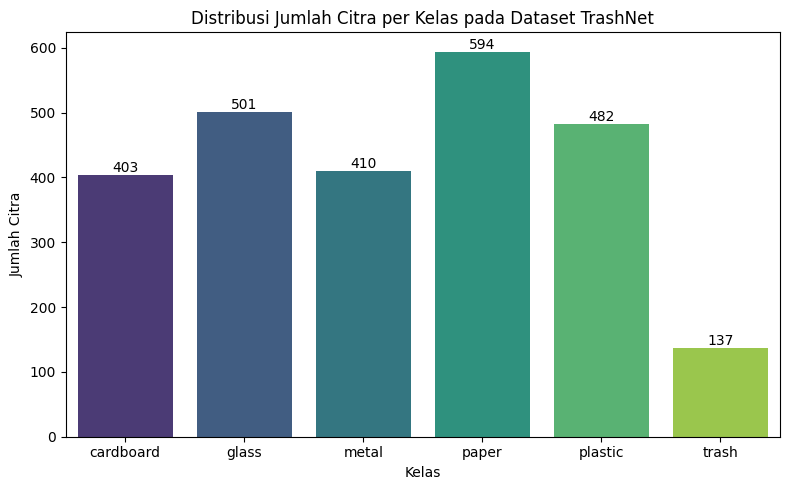

label
paper        594
glass        501
plastic      482
metal        410
cardboard    403
trash        137
Name: count, dtype: int64


In [5]:
## 3.2 Distribusi jumlah citra per kelas
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x="label",
    hue="label",
    order=CLASS_NAMES,
    palette="viridis",
    legend=False
)
ax.set_title("Distribusi Jumlah Citra per Kelas pada Dataset TrashNet")
ax.set_xlabel("Kelas")
ax.set_ylabel("Jumlah Citra")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIRS["figures"], "01_distribusi_kelas.png"), dpi=150)
plt.show()

print(df["label"].value_counts())

## 3.3 Visualisasi sampel citra tiap kelas

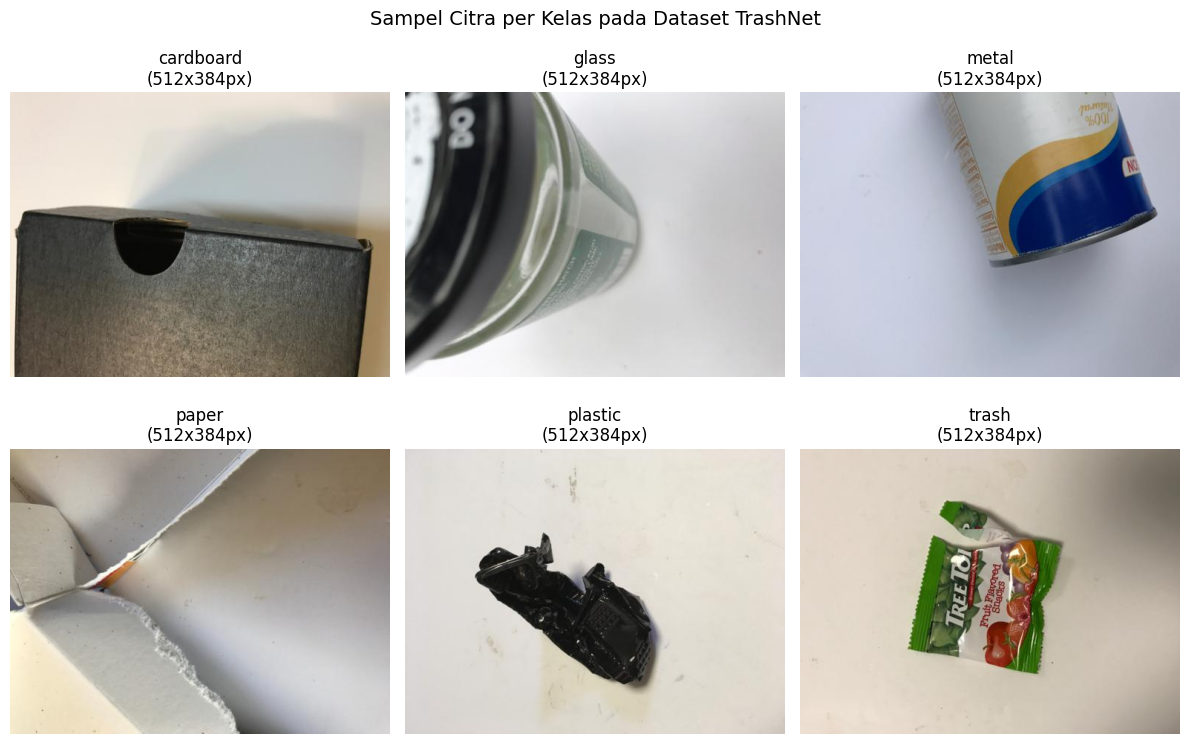

In [6]:
# 3.3 Visualisasi sampel citra tiap kelas
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, class_name in enumerate(CLASS_NAMES):
    sample_path = df[df["label"] == class_name]["filepath"].iloc[0]
    img = Image.open(sample_path)
    ax = axes[idx // 3, idx % 3]
    ax.imshow(img)
    ax.set_title(f"{class_name}\n({img.size[0]}x{img.size[1]}px)")
    ax.axis("off")
plt.suptitle("Sampel Citra per Kelas pada Dataset TrashNet", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIRS["figures"], "02_sampel_citra_per_kelas.png"), dpi=150)
plt.show()

## 3.4 Cek resolusi citra & deteksi file corrupt

In [7]:
# 3.4 Cek resolusi citra & deteksi file corrupt
resolutions = []
corrupt_files = []

for fp in df["filepath"]:
    try:
        with Image.open(fp) as img:
            resolutions.append(img.size)
    except Exception as e:
        corrupt_files.append(fp)

res_series = pd.Series(resolutions)
print("Resolusi unik ditemukan:", res_series.value_counts().head())
print(f"\nJumlah file corrupt: {len(corrupt_files)}")
if corrupt_files:
    print("Daftar file corrupt:", corrupt_files)

# Simpan laporan EDA ke file log
eda_report = {
    "total_citra": len(df),
    "resolusi_unik": {str(k): int(v) for k, v in res_series.value_counts().items()},
    "jumlah_file_corrupt": len(corrupt_files),
    "file_corrupt": corrupt_files,
}
with open(os.path.join(OUTPUT_DIRS["logs"], "eda_report.json"), "w") as f:
    json.dump(eda_report, f, indent=2)

print("\nLaporan EDA disimpan ke outputs/logs/eda_report.json")

Resolusi unik ditemukan: (512, 384)    2527
Name: count, dtype: int64

Jumlah file corrupt: 0

Laporan EDA disimpan ke outputs/logs/eda_report.json


# 4. Split Dataset (Train/Val/Test 70:15:15)

Pada tahap ini data dibagi sebelum ke tahap prapemrosesan untuk mencegah *data leakage*, augmentasi nanti hanya diterapkan pada data latih. Split menggunakan *stratified sampling*
agar proporsi tiap kelas tetap terjaga di ketiga subset. Hasil split disimpan sebagai
file CSV agar dapat diperiksa ulang atau dipakai kembali tanpa perlu re-split.

## 4.1 Split data: 70% train, 15% val, 15% test (stratified by label)

In [8]:
# 4.1 Split data: 70% train, 15% val, 15% test (stratified by label)

# Split pertama: train (70%) vs sisanya (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=(SPLIT_RATIO["val"] + SPLIT_RATIO["test"]),
    stratify=df["label"],
    random_state=SEED,
)

# Split kedua: bagi sisanya (30%) jadi validation (15%) dan test (15%) -> masing2 50% dari temp_df
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train : {len(train_df)} citra")
print(f"Val   : {len(val_df)} citra")
print(f"Test  : {len(test_df)} citra")
print(f"Total : {len(train_df) + len(val_df) + len(test_df)} citra")

# Simpan hasil split ke file CSV
train_df.to_csv(os.path.join(OUTPUT_DIRS["data"], "train_split.csv"), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIRS["data"], "val_split.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIRS["data"], "test_split.csv"), index=False)

print("\nFile split tersimpan di outputs/data/:")
print("  - train_split.csv")
print("  - val_split.csv")
print("  - test_split.csv")

Train : 1768 citra
Val   : 379 citra
Test  : 380 citra
Total : 2527 citra

File split tersimpan di outputs/data/:
  - train_split.csv
  - val_split.csv
  - test_split.csv


In [9]:
train_df.head()

,filepath,label
0,/kaggle/input/datasets/feyzazkefe/trashnet/dat...,plastic
1,/kaggle/input/datasets/feyzazkefe/trashnet/dat...,cardboard
2,/kaggle/input/datasets/feyzazkefe/trashnet/dat...,cardboard
3,/kaggle/input/datasets/feyzazkefe/trashnet/dat...,cardboard
4,/kaggle/input/datasets/feyzazkefe/trashnet/dat...,metal


## 4.2 Verifikasi distribusi kelas tiap partisi tetap proporsional

           Train  Validation  Test
label                             
cardboard    282          61    60
glass        350          75    76
metal        287          61    62
paper        416          89    89
plastic      337          72    73
trash         96          21    20
Total       1768         379   380


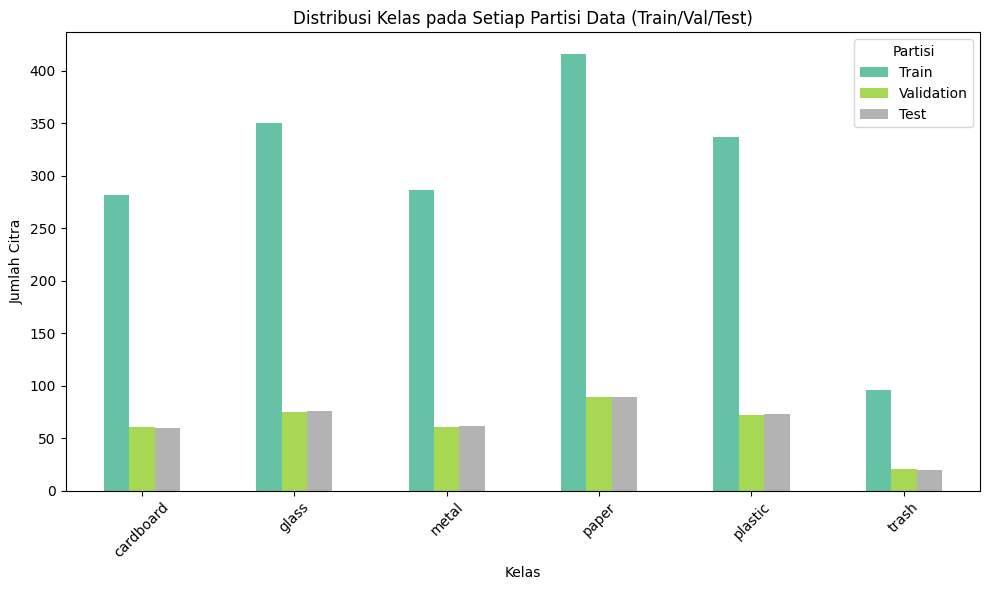

In [10]:
# 4.2 Verifikasi distribusi kelas tiap partisi tetap proporsional

split_summary = pd.DataFrame({
    "Train": train_df["label"].value_counts().reindex(CLASS_NAMES),
    "Validation": val_df["label"].value_counts().reindex(CLASS_NAMES),
    "Test": test_df["label"].value_counts().reindex(CLASS_NAMES),
})
split_summary.loc["Total"] = split_summary.sum()
print(split_summary)

# Simpan ringkasan split juga sebagai CSV
split_summary.to_csv(os.path.join(OUTPUT_DIRS["data"], "split_summary.csv"))

# Visualisasi perbandingan jumlah citra per partisi
split_summary.drop("Total").plot(kind="bar", figsize=(10, 6), colormap="Set2")
plt.title("Distribusi Kelas pada Setiap Partisi Data (Train/Val/Test)")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Citra")
plt.xticks(rotation=45)
plt.legend(title="Partisi")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIRS["figures"], "03_distribusi_split_dataset.png"), dpi=150)
plt.show()

# 5. Prapemrosesan Data (Preprocessing & Augmentasi)

Citra ditransformasikan ke format optimal untuk CNN berupa resize seragam,
normalisasi skala piksel, dan augmentasi (khusus data latih) untuk memperkaya variasi
serta mencegah *overfitting*.

## 5.1 Load kembali hasil split dari file CSV

In [11]:
# 5.1 Load kembali hasil split dari file CSV
train_df = pd.read_csv(os.path.join(OUTPUT_DIRS["data"], "train_split.csv"))
val_df   = pd.read_csv(os.path.join(OUTPUT_DIRS["data"], "val_split.csv"))
test_df  = pd.read_csv(os.path.join(OUTPUT_DIRS["data"], "test_split.csv"))

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

# Mapping label -> index (urutan tetap sesuai CLASS_NAMES agar konsisten di seluruh notebook)
class_indices = {name: idx for idx, name in enumerate(CLASS_NAMES)}
idx_to_class = {idx: name for name, idx in class_indices.items()}
print("Class indices:", class_indices)

Train : 1768 | Val : 379 | Test : 380
Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


## 5.2 Fungsi load_and_preprocess

In [12]:
# 5.2 Fungsi load + decode + resize + normalisasi

def load_and_preprocess(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=IMG_CHANNELS)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = image / 255.0  # normalisasi 0-1
    return image, label

print("Fungsi load_and_preprocess() siap (decode + resize + normalisasi).")

Fungsi load_and_preprocess() siap (decode + resize + normalisasi).


<!-- ## 5.3 Bangun generator dari dataframe (resize otomatis ke IMG_SIZE x IMG_SIZE) -->
## 5.3 Fungsi augmentasi

In [13]:
# 5.3 Fungsi augmentasi (hanya untuk data training)

data_augmentation_curated = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomTranslation(0.1, 0.1, fill_mode="nearest"),
])

def augment_batch(images, labels):
    """
    Augmentasi diterapkan ke seluruh batch sekaligus (vektorisasi), bukan per-citra.
    images berbentuk (batch_size, H, W, C).
    """
    images = data_augmentation_curated(images, training=True)
    images = tf.clip_by_value(images, 0.0, 1.0)
    return images, labels

print("Fungsi augment_batch() siap: RandomFlip + RandomTranslation (batch-level, "
      "vektorisasi penuh, hasil kurasi eksperimen ablasi).")

Fungsi augment_batch() siap: RandomFlip + RandomTranslation (batch-level, vektorisasi penuh, hasil kurasi eksperimen ablasi).


## 5.4 Pipeline tf.data.Dataset (train/val/test)

In [14]:
# 5.4 Bangun pipeline tf.data.Dataset

AUTOTUNE = tf.data.AUTOTUNE

def encode_labels(df):
    return df["label"].map(class_indices).values

def build_dataset(df, training: bool, batch_size=BATCH_SIZE):
    filepaths = df["filepath"].values
    labels = tf.keras.utils.to_categorical(encode_labels(df), num_classes=NUM_CLASSES)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()                     # cache SEBELUM augmentasi (decode+resize, deterministik)

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.batch(batch_size)
        ds = ds.map(augment_batch, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.batch(batch_size)       # data validation dan test tanpa augmentasi, urutan tetap

    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = build_dataset(train_df, training=True)
val_ds   = build_dataset(val_df, training=False)
test_ds  = build_dataset(test_df, training=False) 

steps_per_epoch = len(train_df) // BATCH_SIZE + (1 if len(train_df) % BATCH_SIZE else 0)
val_steps       = len(val_df) // BATCH_SIZE + (1 if len(val_df) % BATCH_SIZE else 0)

print(f"steps_per_epoch (train): {steps_per_epoch} | val_steps: {val_steps}")

steps_per_epoch (train): 56 | val_steps: 12


## 5.5 Visualisasi alur preprocessing bertahap

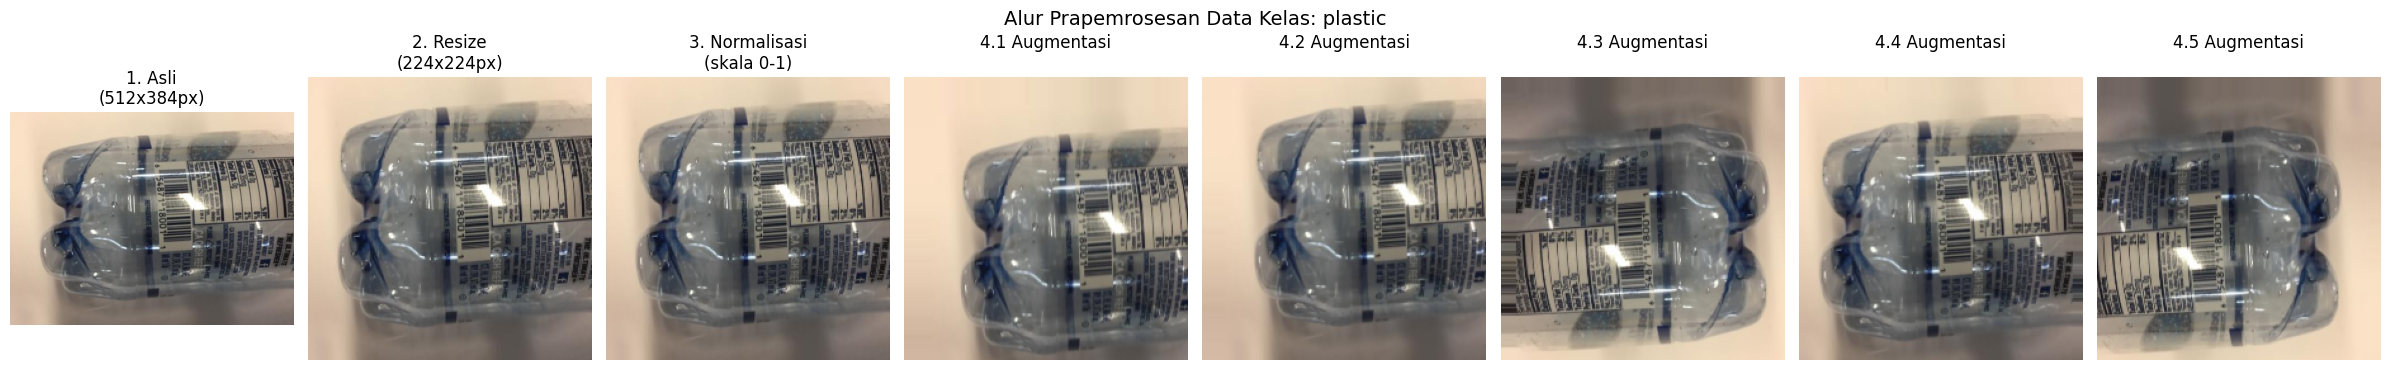

In [15]:
# 5.5 Visualisasi alur preprocessing bertahap:
# Gambar Asli -> Resize -> Normalisasi -> beberapa hasil Augmentasi

sample_row = train_df.iloc[0]
img_original = Image.open(sample_row["filepath"])
img_original_arr = np.array(img_original)

img_resized = tf.image.resize(img_original_arr, [IMG_SIZE, IMG_SIZE])
img_resized_uint8 = tf.cast(img_resized, tf.uint8).numpy()

img_normalized = img_resized / 255.0

# Bikin batch dummy (5 salinan citra yang sama) agar augment_batch() bisa diuji per-batch
dummy_batch = tf.stack([img_normalized] * 5)
augmented_batch = data_augmentation_curated(dummy_batch, training=True)
augmented_batch = tf.clip_by_value(augmented_batch, 0.0, 1.0).numpy()

n_cols = 3 + 5
fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 4))

axes[0].imshow(img_original_arr)
axes[0].set_title(f"1. Asli\n({img_original_arr.shape[1]}x{img_original_arr.shape[0]}px)")
axes[0].axis("off")

axes[1].imshow(img_resized_uint8)
axes[1].set_title(f"2. Resize\n({IMG_SIZE}x{IMG_SIZE}px)")
axes[1].axis("off")

axes[2].imshow(img_normalized.numpy())
axes[2].set_title("3. Normalisasi\n(skala 0-1)")
axes[2].axis("off")

for i in range(5):
    axes[3 + i].imshow(augmented_batch[i])
    axes[3 + i].set_title(f"4.{i+1} Augmentasi\n")
    axes[3 + i].axis("off")

plt.suptitle(f"Alur Prapemrosesan Data Kelas: {sample_row['label']}", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIRS["figures"], "04_alur_preprocessing_augmentasi.png"), dpi=150)
plt.show()

## 5.6 Informasi data training setelah augmentasi

In [16]:
# 5.6 Informasi volume data training

print("=== Informasi Data Training (Pipeline tf.data.Dataset) ===")
print(f"Jumlah citra latih asli (setelah cache, sebelum augmentasi) : {len(train_df)}")
print(f"Batch size                                                  : {BATCH_SIZE}")
print(f"Steps per epoch                                             : {steps_per_epoch}")
print(f"Total citra teraugmentasi per epoch                         : {steps_per_epoch * BATCH_SIZE}")
print("Catatan: decode+resize citra HANYA dijalankan sekali (di-cache pada epoch pertama); "
      "augmentasi tetap dijalankan ulang dengan parameter acak baru tiap epoch.")

augmentation_info = {
    "jumlah_citra_latih_asli": int(len(train_df)),
    "batch_size": BATCH_SIZE,
    "steps_per_epoch": int(steps_per_epoch),
    "citra_teraugmentasi_per_epoch": int(len(train_df)),
    "strategi_cache": "decode+resize di-cache sekali; augmentasi tetap acak tiap epoch (setelah cache)",
}
with open(os.path.join(OUTPUT_DIRS["logs"], "augmentation_info.json"), "w") as f:
    json.dump(augmentation_info, f, indent=2)

=== Informasi Data Training (Pipeline tf.data.Dataset) ===
Jumlah citra latih asli (setelah cache, sebelum augmentasi) : 1768
Batch size                                                  : 32
Steps per epoch                                             : 56
Total citra teraugmentasi per epoch                         : 1792
Catatan: decode+resize citra HANYA dijalankan sekali (di-cache pada epoch pertama); augmentasi tetap dijalankan ulang dengan parameter acak baru tiap epoch.


# 6. Perancangan Arsitektur Dasar CNN

Pada tahap ini dibangun fungsi arsitektur CNN yang umum dapat menerima
hyperparameter sebagai argumen, sehingga fungsi yang sama bisa dipakai untuk:
1. Model baseline (hyperparameter default),
2. Evaluasi *fitness* tiap paus di WOA,
3. Model final CNN-WOA.

Arsitektur dasar: 2 blok Conv2D+MaxPooling, Flatten, Dense 128, Dropout, output Softmax
6 kelas, namun jumlah blok konvolusi, dropout rate, learning rate, dan optimizer
dibuat fleksibel sesuai parameter yang di-*passing*.

## 6.1 Fungsi umum untuk membangun model CNN sesuai hyperparameter yang diberikan

In [17]:
# 6.1 Fungsi umum untuk membangun model CNN sesuai hyperparameter yang diberikan

def build_cnn_model(hyperparams: dict) -> keras.Model:
    """
    Membangun model CNN custom berdasarkan hyperparameter yang diberikan.

    Parameters
    ----------
    hyperparams : dict
        - n_conv_layers : int    -> jumlah lapisan konvolusi (2-5)
        - learning_rate : float  -> learning rate optimizer (1e-4 - 1e-2)
        - dropout_rate  : float  -> dropout rate (0.1 - 0.5)
        - optimizer     : str    -> 'adam', 'adamw', atau 'rmsprop'
        - filters_base  : int    -> jumlah filter awal (default 32, dobel tiap layer)

    Returns
    -------
    keras.Model : model CNN yang sudah di-compile
    """
    n_conv_layers = hyperparams.get("n_conv_layers", 2)
    learning_rate = hyperparams.get("learning_rate", 0.001)
    dropout_rate  = hyperparams.get("dropout_rate", 0.5)
    optimizer_name = hyperparams.get("optimizer", "adam")
    filters_base = hyperparams.get("filters_base", 32)

    model = keras.Sequential(name="CNN")
    model.add(keras.Input(shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)))

    # Lapisan konvolusi dinamis: jumlah filter dobel tiap layer (32 -> 64 -> 128 -> ...)
    for i in range(n_conv_layers):
        filters = filters_base * (2 ** i)
        model.add(keras.layers.Conv2D(filters, (3, 3), activation="relu", padding="same"))
        model.add(keras.layers.MaxPooling2D((2, 2)))

    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(128, activation="relu"))
    model.add(keras.layers.Dropout(dropout_rate))
    model.add(keras.layers.Dense(NUM_CLASSES, activation="softmax"))

    # Pilih optimizer berdasar parameter kategorikal
    if optimizer_name.lower() == "adam":
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == "rmsprop":
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name.lower() == "adamw":
        opt = keras.optimizers.AdamW(learning_rate=learning_rate)
    else:
        raise ValueError(f"Optimizer '{optimizer_name}' tidak dikenali.")

    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    return model


print("Fungsi build_cnn_model() siap digunakan.")

Fungsi build_cnn_model() siap digunakan.


## 6.2 Bangun & tampilkan arsitektur CNN default

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,710,406 (98.08 MB)

 Trainable params: 25,710,406 (98.08 MB)

 Non-trainable params: 0 (0.00 B)

Diagram arsitektur tersimpan:
/kaggle/working/outputs/figures/05_arsitektur_cnn_default.png


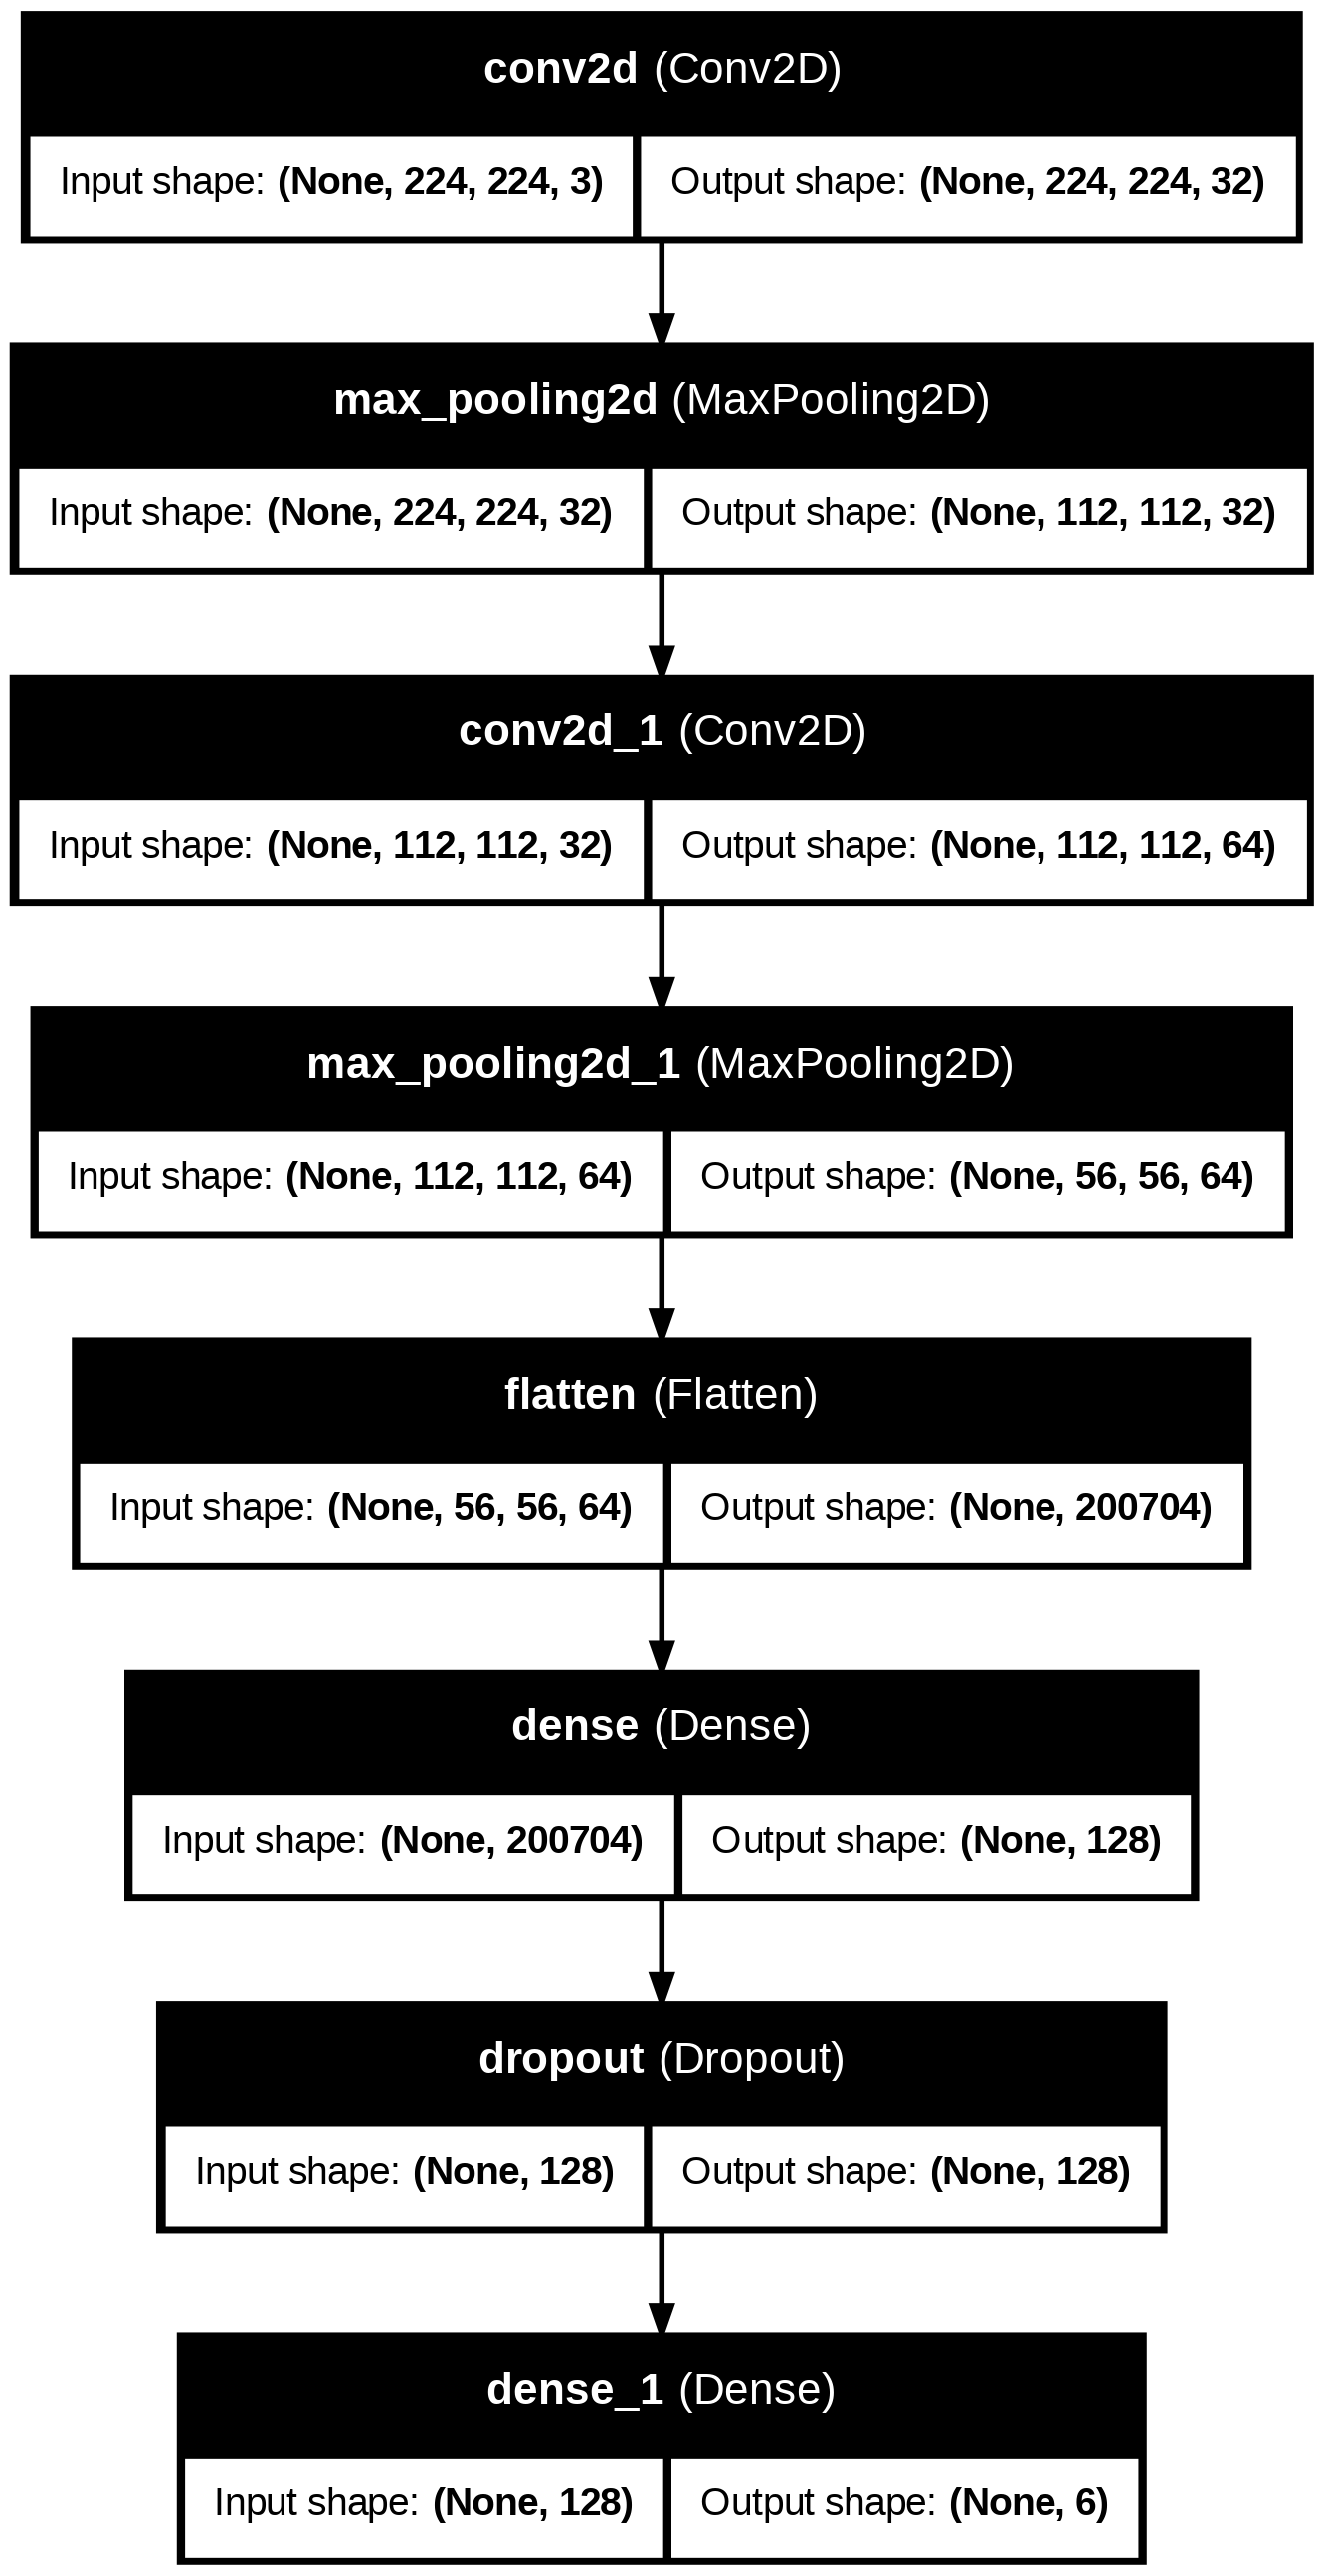

In [18]:
# 6.2 Bangun & tampilkan arsitektur CNN default

DEFAULT_HYPERPARAMS = {
    "n_conv_layers": 2,
    "learning_rate": 0.001,
    "dropout_rate": 0.5,
    "optimizer": "adam",
    "epoch": 30,
    "filters_base": 32,
}
# Bangun model
# Hilangkan komen with strategy.scope() jika menggunakan GPU T4 x2
with strategy.scope():
    default_model = build_cnn_model(DEFAULT_HYPERPARAMS)

# Tampilkan summary model
default_model.summary()

# Simpan summary ke file
summary_lines = []
default_model.summary(
    print_fn=lambda line: summary_lines.append(line)
)
with open(
    os.path.join(
        OUTPUT_DIRS["logs"],
        "model_architecture_summary.txt"
    ),
    "w"
) as f:
    f.write("\n".join(summary_lines))

# Visualisasi arsitektur CNN
architecture_path = os.path.join(
    OUTPUT_DIRS["figures"],
    "05_arsitektur_cnn_default.png"
)
keras.utils.plot_model(
    default_model,
    to_file=architecture_path,
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=200
)
print(
    f"Diagram arsitektur tersimpan:\n{architecture_path}"
)

# Tampilkan gambar langsung
from IPython.display import Image, display
display(
    Image(filename=architecture_path,
         width=500
    )
)

# Bersihkan memori
del default_model
keras.backend.clear_session()

# 7. Implementasi Whale Optimization Algorithm (WOA)

Tahap ini mencari kombinasi hyperparameter CNN (jumlah lapisan konvolusi, learning
rate, dropout rate, optimizer, epoch) dengan nilai *error* (loss) validasi yang minimal, tanpa
pencarian manual/brute-force.

Cara kerja WOA: tiap paus merepresentasikan satu kandidat kombinasi hyperparameter
(1 individu = 1 titik di ruang pencarian). Posisi diperbarui lewat 3 mekanisme:
1. Encircling prey: bergerak menuju solusi terbaik saat ini.
2. Spiral bubble-net attacking: bergerak spiral menuju solusi terbaik (eksploitasi).
3. Search for prey: bergerak menuju agen acak (eksplorasi), hindari solusi lokal.

## 7.1 Ruang pencarian (search space)

In [19]:
# 7.1 Ruang pencarian (search space)

SEARCH_SPACE = {
    "n_conv_layers": {"type": "int",         "low": 2,    "high": 5},
    "learning_rate": {"type": "continuous",  "low": 1e-4, "high": 1e-2},
    "dropout_rate":  {"type": "continuous",  "low": 0.1,  "high": 0.5},
    "optimizer":     {"type": "categorical", "options": ["adam", "rmsprop", "adamw"]},
    "epoch":         {"type": "int",         "low": 10,   "high": 50},
}

# Urutan dimensi tetap (dipakai buat konversi vektor <-> dict hyperparameter)
PARAM_ORDER = list(SEARCH_SPACE.keys())
DIM = len(PARAM_ORDER)  # 5 dimensi

print("Search space WOA:")
for k, v in SEARCH_SPACE.items():
    print(f"  {k:15s}: {v}")

Search space WOA:
  n_conv_layers  : {'type': 'int', 'low': 2, 'high': 5}
  learning_rate  : {'type': 'continuous', 'low': 0.0001, 'high': 0.01}
  dropout_rate   : {'type': 'continuous', 'low': 0.1, 'high': 0.5}
  optimizer      : {'type': 'categorical', 'options': ['adam', 'rmsprop', 'adamw']}
  epoch          : {'type': 'int', 'low': 10, 'high': 50}


## 7.2a Konversi: vektor posisi kontinu -> dict hyperparameter asli

In [20]:
# 7.2a Konversi: vektor posisi kontinu -> dict hyperparameter asli

def decode_position(position: np.ndarray) -> dict:
    """
    Mengubah vektor posisi paus (nilai 0-1 tiap dimensi) menjadi dict hyperparameter
    sesuai batas & tipe data di SEARCH_SPACE.
    """
    hyperparams = {}
    for i, param_name in enumerate(PARAM_ORDER):
        spec = SEARCH_SPACE[param_name]
        val = position[i]  # nilai ternormalisasi 0-1

        if spec["type"] == "int":
            raw = spec["low"] + val * (spec["high"] - spec["low"])
            hyperparams[param_name] = int(round(raw))
        elif spec["type"] == "continuous":
            raw = spec["low"] + val * (spec["high"] - spec["low"])
            hyperparams[param_name] = float(raw)
        elif spec["type"] == "categorical":
            options = spec["options"]
            idx = int(val * len(options))
            idx = min(idx, len(options) - 1)  # clip kalau val persis 1.0
            hyperparams[param_name] = options[idx]
    return hyperparams


def clip_position(position: np.ndarray) -> np.ndarray:
    """Pastikan tiap dimensi posisi tetap dalam batas [0, 1]."""
    return np.clip(position, 0.0, 1.0)


# Uji cepat fungsi decode
test_vector = np.array([0.5, 0.3, 0.5, 0.7, 0.4])
print("Contoh decode vektor:", test_vector, "->", decode_position(test_vector))

Contoh decode vektor: [0.5 0.3 0.5 0.7 0.4] -> {'n_conv_layers': 4, 'learning_rate': 0.00307, 'dropout_rate': 0.30000000000000004, 'optimizer': 'adamw', 'epoch': 26}


## 7.3 Fungsi fitness: training cepat CNN, return loss validasi sebagai nilai fitness

In [21]:
# 7.3 Fungsi fitness: training cepat CNN, return loss validasi sebagai nilai fitness

def fitness_function(position: np.ndarray, verbose=0) -> float:
    """
    Evaluasi 1 kandidat hyperparameter (posisi paus):
    1. Decode posisi -> hyperparameter
    2. Bangun model CNN
    3. Training menggunakan epoch sesuai hp["epoch"], dengan ReduceLROnPlateau
       (turunkan lr otomatis saat val_loss stagnan) + EarlyStopping (hentikan
       training kalau val_loss tak membaik lagi meski lr sudah diturunkan)
    4. Return val_loss terbaik (dari EarlyStopping restore_best_weights) 
        sebagai nilai fitness (semakin kecil semakin baik)
    """
    hyperparams = decode_position(position)

    keras.backend.clear_session()

    # Hilangkan komen with strategy.scope() jika menggunakan GPU T4 x2
    with strategy.scope():
        model = build_cnn_model(hyperparams)

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=FITNESS_LR_FACTOR,
        patience=FITNESS_LR_PATIENCE,
        min_lr=FITNESS_MIN_LR,
        verbose=0,
    )
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=FITNESS_EARLY_STOP_PATIENCE,
        restore_best_weights=True,
    )

    history = model.fit(
        train_ds,                 # sebelumnya: train_generator
        validation_data=val_ds,   # sebelumnya: val_generator
        epochs=hyperparams["epoch"],       # <-- FIX: pakai epoch milik candidate ini
        callbacks=[reduce_lr, early_stop],
        verbose=verbose,
    )

    val_loss = min(history.history["val_loss"])  # nilai terbaik selama training candidate ini

    del model
    keras.backend.clear_session()

    return val_loss, hyperparams


print("Fungsi fitness_function() siap. Estimasi waktu per evaluasi akan diukur saat run WOA.")

Fungsi fitness_function() siap. Estimasi waktu per evaluasi akan diukur saat run WOA.


## 7.4 Inisialisasi populasi paus secara acak dalam ruang pencarian [0,1]^DIM

In [22]:
# 7.4 Inisialisasi populasi paus secara acak dalam ruang pencarian [0,1]^DIM

def initialize_population(n_whales: int) -> np.ndarray:
    """Inisialisasi posisi awal N paus secara random uniform di [0,1] tiap dimensi."""
    return np.random.uniform(low=0.0, high=1.0, size=(n_whales, DIM))

# Contoh inisialisasi (akan dipanggil ulang di main loop 7.6)
sample_population = initialize_population(n_whales=5)
print("Contoh populasi awal (5 paus, 5 dimensi):")
print(sample_population)

Contoh populasi awal (5 paus, 5 dimensi):
[[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]
 [0.15599452 0.05808361 0.86617615 0.60111501 0.70807258]
 [0.02058449 0.96990985 0.83244264 0.21233911 0.18182497]
 [0.18340451 0.30424224 0.52475643 0.43194502 0.29122914]
 [0.61185289 0.13949386 0.29214465 0.36636184 0.45606998]]


## 7.5 Update posisi paus sesuai mekanisme WOA (persamaan 2-8)

In [23]:
# 7.5 Update posisi paus sesuai mekanisme WOA (persamaan 2-8)

def update_whale_position(
    position: np.ndarray,
    best_position: np.ndarray,
    a: float,
    population: np.ndarray,
) -> np.ndarray:
    """
    Update posisi 1 paus berdasarkan mekanisme WOA:
    - p >= 0.5           -> spiral bubble-net attacking
    - p < 0.5 & |A| < 1  -> encircling prey
    - p < 0.5 & |A| >= 1 -> search for prey / eksplorasi
    """
    r = np.random.uniform(0, 1, size=DIM)
    A = 2 * a * r - a 
    C = 2 * np.random.uniform(0, 1, size=DIM) 
    p = np.random.uniform(0, 1) 

    if p >= 0.5:
        # --- Spiral bubble-net attacking (persamaan 7) ---
        b = 1.0  # konstanta bentuk spiral
        l = np.random.uniform(-1, 1, size=DIM)
        # D' = | X*^t - Xi^t |
        D_prime = np.abs(best_position - position) 
        # X_i^(t+1) = D' * e^(b*l) * cos(2πl) + X*^t
        new_position = D_prime * np.exp(b * l) * np.cos(2 * np.pi * l) + best_position
        
    else:
        if np.linalg.norm(A) < 1:
            # --- Encircling prey (persamaan 2-3) ---
            # D = | C × X*^t - X_i^t |
            D = np.abs(C * best_position - position)
            # X_i^(t+1) = X*^t - A.D
            new_position = best_position - A * D
        else:
            # --- Search for prey / eksplorasi (persamaan 8) ---
            random_whale = population[np.random.randint(0, population.shape[0])]
            # D = | C * X_rand^t - X_i^t |
            D = np.abs(C * random_whale - position)
            # X_i^(t+1) = X_rand^t - A * D
            new_position = random_whale - A * D

    return clip_position(new_position)


print("Fungsi update_whale_position() siap (3 mekanisme: encircling, spiral, search).")

Fungsi update_whale_position() siap (3 mekanisme: encircling, spiral, search).


## 7.6 Main loop WOA jalankan optimasi hyperparameter

In [24]:
# 7.6 Main loop WOA jalankan optimasi hyperparameter

N_WHALES = 6          # ukuran populasi (jaga kecil krn training tiap paus mahal)
MAX_ITER = 8          # jumlah iterasi maksimum

def run_woa(n_whales=N_WHALES, max_iter=MAX_ITER, verbose=True):
    """
    Implementasi WOA sesuai pseudocode asli Mirjalili & Lewis (2016):
    1. Inisialisasi populasi paus
    2. Evaluasi fitness dan cari solusi terbaik
    3. WHILE t < max_iter:
       a. Update posisi semua paus
       b. Evaluasi fitness posisi BARU
       c. Update solusi terbaik
    """
    # 1. Inisialisasi populasi paus
    population = initialize_population(n_whales)
    
    # 2. Evaluasi fitness awal setiap agen (SEBELUM loop)
    best_position = None
    best_fitness = np.inf
    best_hyperparams = None
    
    fitness_history = []
    all_evaluations = []
    
    print("Evaluasi fitness awal populasi...")
    for i in range(n_whales):
        val_loss, hp = fitness_function(population[i], verbose=0)
        
        all_evaluations.append({
            "iteration": 0,  # Iterasi awal (belum update)
            "whale_idx": i,
            "val_loss": val_loss,
            **hp,
        })
        
        if val_loss < best_fitness:
            best_fitness = val_loss
            best_position = population[i].copy()
            best_hyperparams = hp
    
    start_time = time.time()
    
    # 3. MAIN LOOP (while t < max_iter)
    for t in range(max_iter):
        # Update parameter a (menurun linier dari 2 ke 0)
        a = 2 - t * (2 / max_iter)
        
        if verbose:
            print(f"\n[Iterasi {t+1}/{max_iter}] a = {a:.4f}")
        
        # STEP 1: Update posisi SEMUA paus 
        new_population = []
        
        for i in range(n_whales):
            # Update posisi paus ke-i (A, C, l, p di-calculate di dalam fungsi ini)
            new_pos = update_whale_position(
                position=population[i],
                best_position=best_position,
                a=a,
                population=population
            )
            new_population.append(new_pos)
        
        population = np.array(new_population)

        # Periksa batasan posisi paus
        # (Sudah ter-cover di dalam clip_position() di update_whale_position())
        
        # STEP 2: Evaluasi fitness dari posisi baru setiap agen
        current_fitness_scores = []
        
        for i in range(n_whales):
            val_loss, hp = fitness_function(population[i], verbose=0)
            current_fitness_scores.append(val_loss)
            
            all_evaluations.append({
                "iteration": t + 1,
                "whale_idx": i,
                "val_loss": val_loss,
                **hp,
            })
            
            # STEP 3: Update solusi terbaik
            if val_loss < best_fitness:
                best_fitness = val_loss
                best_position = population[i].copy()
                best_hyperparams = hp
                
                if verbose:
                    print(f"  ✓ Paus {i+1}: val_loss={val_loss:.4f} (NEW BEST!)")
            else:
                if verbose:
                    print(f"  - Paus {i+1}: val_loss={val_loss:.4f}")
        
        fitness_history.append(best_fitness)
        
        elapsed = time.time() - start_time
        if verbose:
            print(f"\n[Iterasi {t+1}/{max_iter}] Best val_loss: {best_fitness:.4f} | "
                  f"Waktu: {elapsed/60:.1f} menit")
    
    total_time = time.time() - start_time
    print(f"\n{'='*60}")
    print(f"WOA selesai dalam {total_time/60:.1f} menit.")
    print(f"Hyperparameter terbaik: {best_hyperparams}")
    print(f"Best val_loss: {best_fitness:.4f}")
    print(f"{'='*60}")
    
    return best_hyperparams, best_fitness, fitness_history, all_evaluations

# Jalankan WOA
best_hyperparams, best_fitness, fitness_history, all_evaluations = run_woa()

# Ringkasan epoch aktual yang terpakai selama evaluasi fitness 
epoch_values_used = [ev["epoch"] for ev in all_evaluations]
epoch_usage_summary = {
    "min": int(np.min(epoch_values_used)),
    "max": int(np.max(epoch_values_used)),
    "mean": float(np.mean(epoch_values_used)),
}

# Simpan seluruh histori & hasil WOA ke file 
woa_results = {
    "best_hyperparams": best_hyperparams,
    "best_fitness": best_fitness,
    "fitness_history": fitness_history,
    "n_whales": N_WHALES,
    "max_iter": MAX_ITER,
    "fitness_epoch_strategy": "epoch mengikuti hasil decode posisi tiap paus "
                              f"(search space {SEARCH_SPACE['epoch']['low']}-{SEARCH_SPACE['epoch']['high']}), "
                              f"dengan EarlyStopping(patience={FITNESS_EARLY_STOP_PATIENCE})",
    "fitness_epoch_usage_summary": epoch_usage_summary,
}
with open(os.path.join(OUTPUT_DIRS["logs"], "woa_results.json"), "w") as f:
    json.dump(woa_results, f, indent=2)

pd.DataFrame(all_evaluations).to_csv(
    os.path.join(OUTPUT_DIRS["data"], "woa_all_evaluations.csv"), index=False
)

print("\nHasil WOA disimpan:")
print("  - outputs/logs/woa_results.json")
print("  - outputs/data/woa_all_evaluations.csv")
print(f"\nRingkasan epoch aktual yang dipakai selama evaluasi fitness: {epoch_usage_summary}")

Evaluasi fitness awal populasi...
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/dev

## 7.7 Visualisasi kurva konvergensi WOA

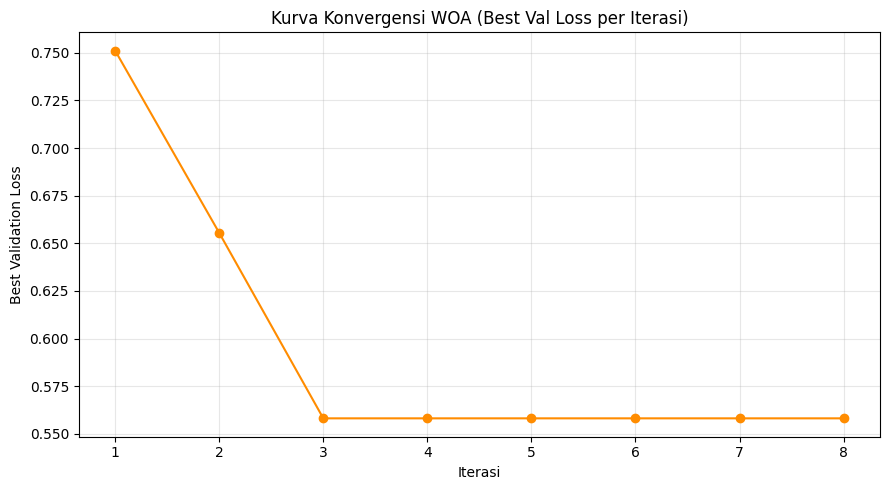

Hyperparameter hasil optimasi WOA:
  n_conv_layers  : 5
  learning_rate  : 0.0003520284452447978
  dropout_rate   : 0.1
  optimizer      : adamw
  epoch          : 50


In [25]:
# 7.7 Visualisasi kurva konvergensi WOA

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(fitness_history) + 1), fitness_history, marker="o", color="darkorange")
plt.title("Kurva Konvergensi WOA (Best Val Loss per Iterasi)")
plt.xlabel("Iterasi")
plt.ylabel("Best Validation Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIRS["figures"], "06_konvergensi_woa.png"), dpi=150)
plt.show()

print("Hyperparameter hasil optimasi WOA:")
for k, v in best_hyperparams.items():
    print(f"  {k:15s}: {v}")

# 8. Training Model Final: CNN Baseline & CNN-WOA

Pada tahap ini kedua model dilatih (full epoch, bukan training cepat
seperti evaluasi fitness) menggunakan fungsi `build_cnn_model()`

- **CNN Baseline**: hyperparameter default (lr=0.001, optimizer Adam, 30 epochs).
- **CNN-WOA**: hyperparameter hasil optimasi Bagian 7.

Checkpoint model terbaik (berdasar val_accuracy) disimpan otomatis ke `outputs/models/`
selama training

## 8.1 Training CNN Baseline (hyperparameter default)

In [26]:
# 8.1 Training CNN Baseline (hyperparameter default)

print("=== Training CNN Baseline ===")
print("Hyperparameter:", DEFAULT_HYPERPARAMS)

keras.backend.clear_session()
# Hilangkan komen with strategy.scope() jika menggunakan GPU T4 x2
with strategy.scope():
    baseline_model = build_cnn_model(DEFAULT_HYPERPARAMS)

baseline_checkpoint_path = os.path.join(OUTPUT_DIRS["models"], "cnn_baseline_best.keras")
baseline_callbacks = [
    keras.callbacks.ModelCheckpoint(
        baseline_checkpoint_path, monitor="val_accuracy", save_best_only=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=FITNESS_LR_FACTOR,
        patience=FITNESS_LR_PATIENCE,
        min_lr=FITNESS_MIN_LR,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=FITNESS_EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
]

baseline_history = baseline_model.fit(
    train_ds,                 
    validation_data=val_ds,   
    epochs=DEFAULT_HYPERPARAMS["epoch"] if "epoch" in DEFAULT_HYPERPARAMS else 30,
    callbacks=baseline_callbacks,
    verbose=1,
)

# Simpan histori training ke CSV
pd.DataFrame(baseline_history.history).to_csv(
    os.path.join(OUTPUT_DIRS["logs"], "baseline_training_history.csv"), index=False
)

print(f"\nModel baseline terbaik tersimpan di: {baseline_checkpoint_path}")

=== Training CNN Baseline ===
Hyperparameter: {'n_conv_layers': 2, 'learning_rate': 0.001, 'dropout_rate': 0.5, 'optimizer': 'adam', 'epoch': 30, 'filters_base': 32}
Epoch 1/30
INFO:tensorflow:Collective all_reduce tensors: 8 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.2305 - loss: 4.1080
Epoch 1: val_accuracy improved from None to 0.35356, saving model to /kaggle/working/outputs/models/cnn_baseline_best.keras

Epoch 1: finished saving model to /kaggle/working/outputs/models/cnn_baseline_best.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.2868 - loss: 2.4242 - val_accuracy: 0.3536 - val_loss: 1.5418 - learning_rate: 0.0010
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.3831 - loss: 1.5251
Epoch 2: val_accuracy improved from 0.35356 to 0.39314, saving model to /kaggle/working/outputs/models/cnn_baseline_best.keras

Epoch 2: finished sa

## 8.2 Training CNN-WOA (hyperparameter hasil optimasi Bagian 7)

In [27]:
# 8.2 Training CNN-WOA (hyperparameter hasil optimasi Bagian 7)

print("=== Training CNN-WOA ===")
print("Hyperparameter optimal:", best_hyperparams)

keras.backend.clear_session()
# Hilangkan komen with strategy.scope() jika menggunakan GPU T4 x2
with strategy.scope():
    woa_model = build_cnn_model(best_hyperparams)

woa_checkpoint_path = os.path.join(OUTPUT_DIRS["models"], "cnn_woa_best.keras")
woa_callbacks = [
    keras.callbacks.ModelCheckpoint(
        woa_checkpoint_path, monitor="val_accuracy", save_best_only=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=FITNESS_LR_FACTOR,
        patience=FITNESS_LR_PATIENCE,
        min_lr=FITNESS_MIN_LR,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=FITNESS_EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
]

woa_history = woa_model.fit(
    train_ds,                 
    validation_data=val_ds,   
    epochs=best_hyperparams["epoch"],
    callbacks=woa_callbacks,
    verbose=1,
)

# Simpan histori training ke CSV
pd.DataFrame(woa_history.history).to_csv(
    os.path.join(OUTPUT_DIRS["logs"], "woa_training_history.csv"), index=False
)

print(f"\nModel CNN-WOA terbaik tersimpan di: {woa_checkpoint_path}")

=== Training CNN-WOA ===
Hyperparameter optimal: {'n_conv_layers': 5, 'learning_rate': 0.0003520284452447978, 'dropout_rate': 0.1, 'optimizer': 'adamw', 'epoch': 50}
Epoch 1/50
INFO:tensorflow:Collective all_reduce tensors: 14 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.1824 - loss: 1.7668
Epoch 1: val_accuracy improved from None to 0.32718, saving model to /kaggle/working/outputs/models/cnn_woa_best.keras

Epoch 1: finished saving model to /kaggle/working/outputs/models/cnn_woa_best.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.2110 - loss: 1.7327 - val_accuracy: 0.3272 - val_loss: 1.6317 - learning_rate: 3.5203e-04
Epoch 2/50
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.3538 - loss: 1.5423
Epoch 2: val_accuracy improved from 0.32718 to 0.42216, saving model to /kaggle/working/outputs/models/cnn_woa_best.keras

Epoch 2: finished saving model 

## 8.3 Visualisasi perbandingan kurva training kedua model (loss & accuracy)

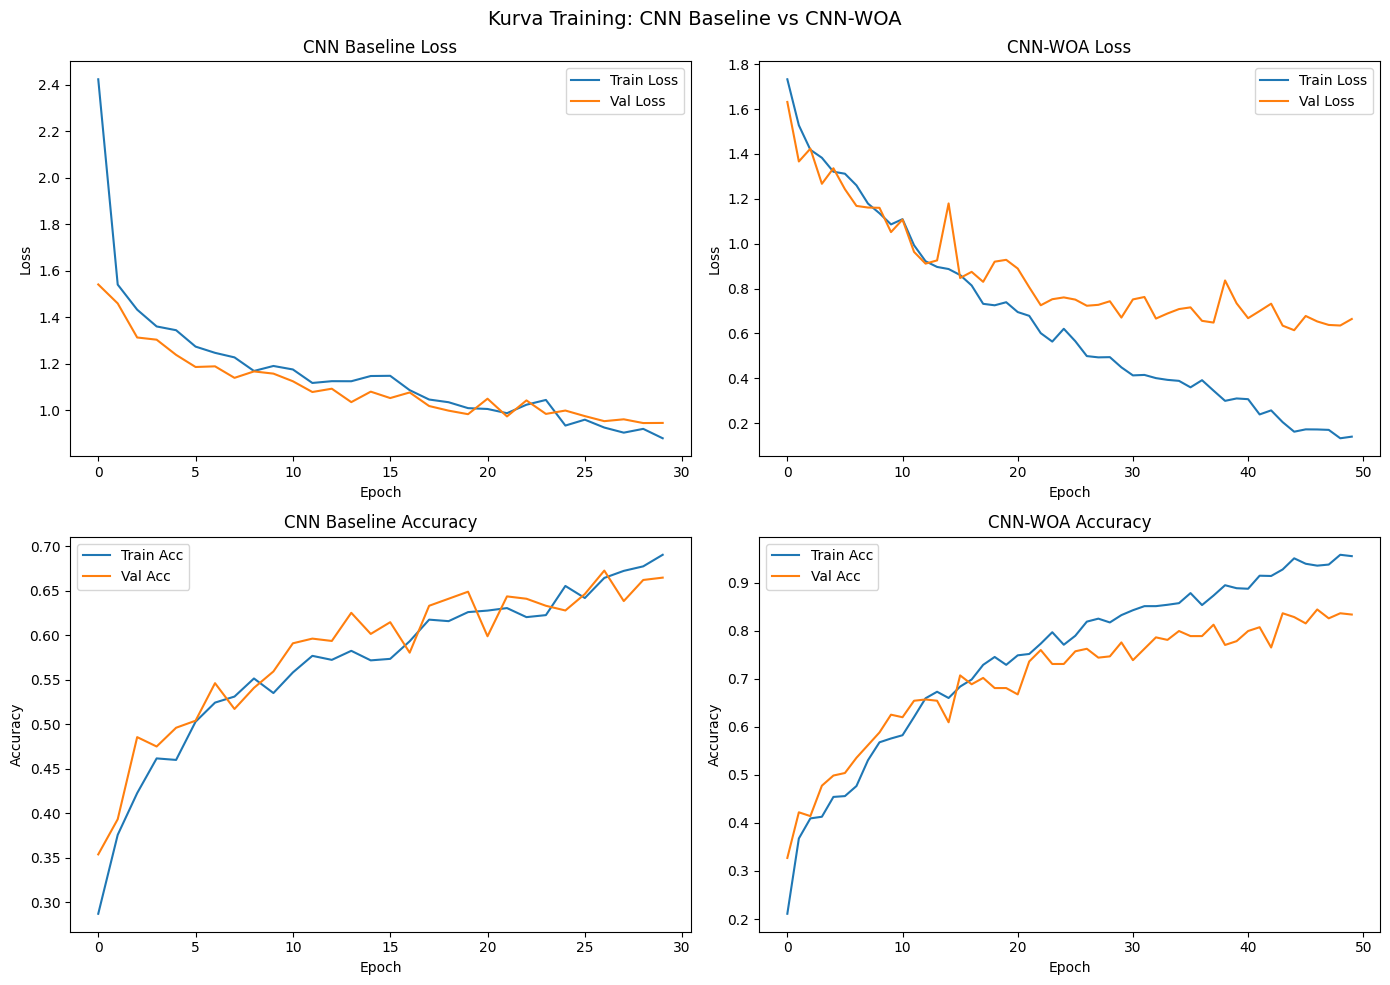

In [28]:
# 8.3 Visualisasi perbandingan kurva training kedua model (loss & accuracy)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(baseline_history.history["loss"], label="Train Loss")
axes[0, 0].plot(baseline_history.history["val_loss"], label="Val Loss")
axes[0, 0].set_title("CNN Baseline Loss")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss"); axes[0, 0].legend()

axes[0, 1].plot(woa_history.history["loss"], label="Train Loss")
axes[0, 1].plot(woa_history.history["val_loss"], label="Val Loss")
axes[0, 1].set_title("CNN-WOA Loss")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Loss"); axes[0, 1].legend()

# Accuracy
axes[1, 0].plot(baseline_history.history["accuracy"], label="Train Acc")
axes[1, 0].plot(baseline_history.history["val_accuracy"], label="Val Acc")
axes[1, 0].set_title("CNN Baseline Accuracy")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Accuracy"); axes[1, 0].legend()

axes[1, 1].plot(woa_history.history["accuracy"], label="Train Acc")
axes[1, 1].plot(woa_history.history["val_accuracy"], label="Val Acc")
axes[1, 1].set_title("CNN-WOA Accuracy")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Accuracy"); axes[1, 1].legend()

plt.suptitle("Kurva Training: CNN Baseline vs CNN-WOA", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIRS["figures"], "07_kurva_training_perbandingan.png"), dpi=150)
plt.show()

# 9. Pengujian Model pada Data Uji (Testing Set)

Tahap ini mengukur performa objektif kedua model (Baseline & CNN-WOA) pada data testing yang
sama sekali belum pernah dilihat selama training maupun proses optimasi WOA.

## 9.1 Load model baseline terbaik (checkpoint) & prediksi pada test set

In [29]:
true_labels = encode_labels(test_df)  

baseline_model_eval = keras.models.load_model(baseline_checkpoint_path)
baseline_pred_probs = baseline_model_eval.predict(test_ds, verbose=1)
baseline_pred_labels = np.argmax(baseline_pred_probs, axis=1)

print("Prediksi CNN Baseline selesai.")
print(f"Jumlah data uji: {len(true_labels)}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
Prediksi CNN Baseline selesai.
Jumlah data uji: 380


## 9.2 Load model CNN-WOA terbaik (checkpoint) & prediksi pada test set

In [30]:
# 9.2 Load model CNN-WOA terbaik (checkpoint) & prediksi pada test set

woa_model_eval = keras.models.load_model(woa_checkpoint_path)
woa_pred_probs = woa_model_eval.predict(test_ds, verbose=1)
woa_pred_labels = np.argmax(woa_pred_probs, axis=1)

print("Prediksi CNN-WOA selesai.")
print(f"Jumlah data uji: {len(true_labels)}")

# Simpan array prediksi mentah (buat audit ulang tanpa re-run model)
np.savez(
    os.path.join(OUTPUT_DIRS["data"], "test_predictions.npz"),
    true_labels=true_labels,
    baseline_pred_probs=baseline_pred_probs,
    baseline_pred_labels=baseline_pred_labels,
    woa_pred_probs=woa_pred_probs,
    woa_pred_labels=woa_pred_labels,
)
print("Prediksi mentah disimpan ke outputs/data/test_predictions.npz")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Prediksi CNN-WOA selesai.
Jumlah data uji: 380
Prediksi mentah disimpan ke outputs/data/test_predictions.npz


# 10. Evaluasi Performa (Confusion Matrix)

Tahap ini menghitung metrik evaluasi standar (akurasi, presisi, recall, F1-score)
serta memvisualisasikan pola kesalahan klasifikasi tiap kelas lewat confusion matrix,
untuk kedua model.

## 10.1 Classification report CNN Baseline

In [31]:
# 10.1 Classification report CNN Baseline

target_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

baseline_report_dict = classification_report(
    true_labels, baseline_pred_labels, target_names=target_names, output_dict=True
)
baseline_report_df = pd.DataFrame(baseline_report_dict).transpose()
print("=== Classification Report: CNN Baseline ===")
print(baseline_report_df.round(4))

baseline_report_df.to_csv(os.path.join(OUTPUT_DIRS["data"], "baseline_classification_report.csv"))

=== Classification Report: CNN Baseline ===
              precision  recall  f1-score   support
cardboard        0.8246  0.7833    0.8034   60.0000
glass            0.5625  0.5921    0.5769   76.0000
metal            0.5303  0.5645    0.5469   62.0000
paper            0.7157  0.8202    0.7644   89.0000
plastic          0.7200  0.4932    0.5854   73.0000
trash            0.5200  0.6500    0.5778   20.0000
accuracy         0.6553  0.6553    0.6553    0.6553
macro avg        0.6455  0.6506    0.6425  380.0000
weighted avg     0.6625  0.6553    0.6534  380.0000


## 10.2 Classification report CNN-WOA

In [32]:
# 10.2 Classification report CNN-WOA

woa_report_dict = classification_report(
    true_labels, woa_pred_labels, target_names=target_names, output_dict=True
)
woa_report_df = pd.DataFrame(woa_report_dict).transpose()
print("=== Classification Report: CNN-WOA ===")
print(woa_report_df.round(4))

woa_report_df.to_csv(os.path.join(OUTPUT_DIRS["data"], "woa_classification_report.csv"))

=== Classification Report: CNN-WOA ===
              precision  recall  f1-score   support
cardboard        0.8644  0.8500    0.8571   60.0000
glass            0.7848  0.8158    0.8000   76.0000
metal            0.7500  0.8710    0.8060   62.0000
paper            0.8265  0.9101    0.8663   89.0000
plastic          0.9167  0.6027    0.7273   73.0000
trash            0.6667  0.8000    0.7273   20.0000
accuracy         0.8105  0.8105    0.8105    0.8105
macro avg        0.8015  0.8083    0.7973  380.0000
weighted avg     0.8206  0.8105    0.8077  380.0000


## 10.3 Confusion matrix heatmap Baseline vs CNN-WOA berdampingan

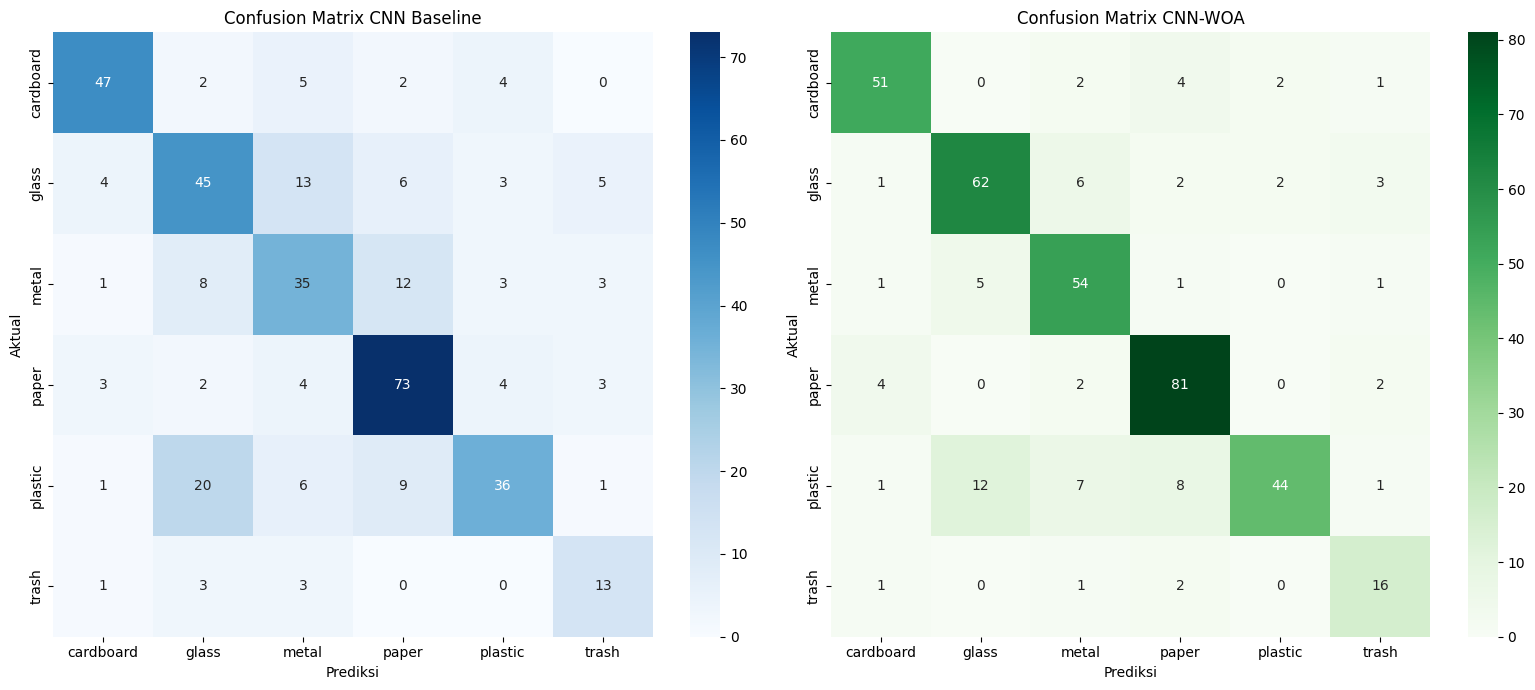

In [33]:
# 10.3 Confusion matrix heatmap Baseline vs CNN-WOA berdampingan

cm_baseline = confusion_matrix(true_labels, baseline_pred_labels)
cm_woa = confusion_matrix(true_labels, woa_pred_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(
    cm_baseline, annot=True, fmt="d", cmap="Blues",
    xticklabels=target_names, yticklabels=target_names, ax=axes[0]
)
axes[0].set_title("Confusion Matrix CNN Baseline")
axes[0].set_xlabel("Prediksi"); axes[0].set_ylabel("Aktual")

sns.heatmap(
    cm_woa, annot=True, fmt="d", cmap="Greens",
    xticklabels=target_names, yticklabels=target_names, ax=axes[1]
)
axes[1].set_title("Confusion Matrix CNN-WOA")
axes[1].set_xlabel("Prediksi"); axes[1].set_ylabel("Aktual")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIRS["figures"], "08_confusion_matrix_perbandingan.png"), dpi=150)
plt.show()

# 11. Analisis Komparatif Baseline vs CNN-WOA

Tahap ini menganalisis apakah WOA memberikan
peningkatan performa yang berarti dibanding CNN dengan hyperparameter default.

## 11.1 Tabel perbandingan metrik utama (accuracy, macro avg precision/recall/F1)

In [34]:
# 11.1 Tabel perbandingan metrik utama (accuracy, macro avg precision/recall/F1)

comparison_metrics = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision (macro avg)", "Recall (macro avg)", "F1-Score (macro avg)"],
    "CNN Baseline": [
        baseline_report_dict["accuracy"],
        baseline_report_dict["macro avg"]["precision"],
        baseline_report_dict["macro avg"]["recall"],
        baseline_report_dict["macro avg"]["f1-score"],
    ],
    "CNN-WOA": [
        woa_report_dict["accuracy"],
        woa_report_dict["macro avg"]["precision"],
        woa_report_dict["macro avg"]["recall"],
        woa_report_dict["macro avg"]["f1-score"],
    ],
})
comparison_metrics["Selisih (Δ)"] = comparison_metrics["CNN-WOA"] - comparison_metrics["CNN Baseline"]
comparison_metrics["Peningkatan (%)"] = (
    comparison_metrics["Selisih (Δ)"] / comparison_metrics["CNN Baseline"] * 100
)

print(comparison_metrics.round(4))
comparison_metrics.to_csv(os.path.join(OUTPUT_DIRS["data"], "comparison_metrics.csv"), index=False)

                  Metrik  CNN Baseline  CNN-WOA  Selisih (Δ)  Peningkatan (%)
0               Accuracy        0.6553   0.8105       0.1553          23.6948
1  Precision (macro avg)        0.6455   0.8015       0.1560          24.1678
2     Recall (macro avg)        0.6506   0.8083       0.1577          24.2429
3   F1-Score (macro avg)        0.6425   0.7973       0.1549          24.1055


## 11.2 Bar chart perbandingan metrik

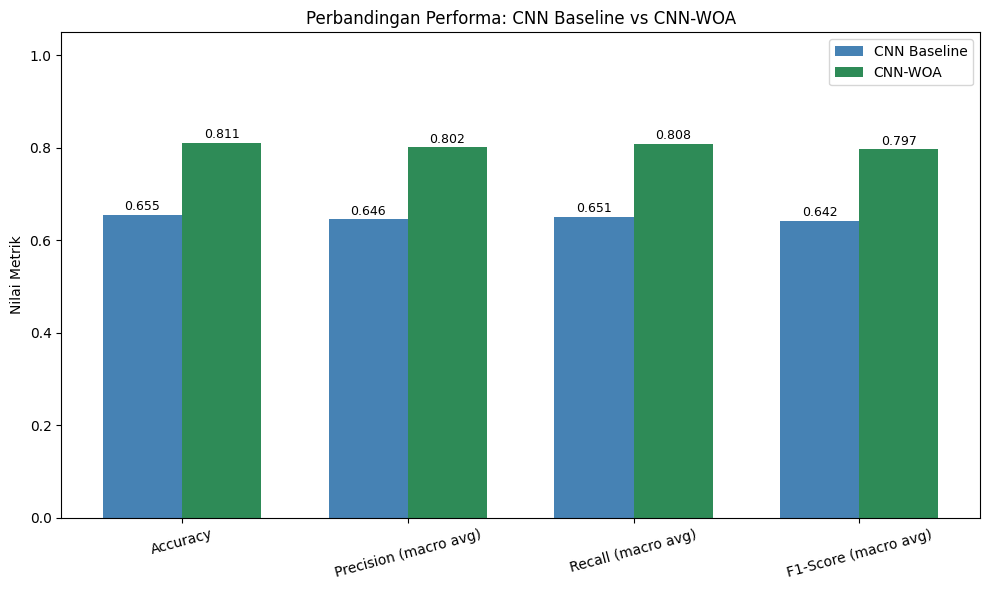

In [35]:
# 11.2 Bar chart perbandingan metrik

x = np.arange(len(comparison_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, comparison_metrics["CNN Baseline"], width, label="CNN Baseline", color="steelblue")
ax.bar(x + width/2, comparison_metrics["CNN-WOA"], width, label="CNN-WOA", color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(comparison_metrics["Metrik"], rotation=15)
ax.set_ylabel("Nilai Metrik")
ax.set_title("Perbandingan Performa: CNN Baseline vs CNN-WOA")
ax.legend()
ax.set_ylim(0, 1.05)

for i, (b, w) in enumerate(zip(comparison_metrics["CNN Baseline"], comparison_metrics["CNN-WOA"])):
    ax.text(i - width/2, b + 0.01, f"{b:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, w + 0.01, f"{w:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIRS["figures"], "09_perbandingan_metrik.png"), dpi=150)
plt.show()

## 11.3 Tabel perbandingan hyperparameter: Default vs Hasil Optimasi WOA

In [36]:
# 11.3 Tabel perbandingan hyperparameter: Default vs Hasil Optimasi WOA

hp_comparison = pd.DataFrame({
    "Hyperparameter": ["Jumlah Lapisan Konvolusi", "Learning Rate", "Dropout Rate", "Optimizer", "Epoch"],
    "Default (Baseline)": [
        DEFAULT_HYPERPARAMS["n_conv_layers"],
        DEFAULT_HYPERPARAMS["learning_rate"],
        DEFAULT_HYPERPARAMS["dropout_rate"],
        DEFAULT_HYPERPARAMS["optimizer"],
        DEFAULT_HYPERPARAMS.get("epoch", 30),
    ],
    "Hasil Optimasi WOA": [
        best_hyperparams["n_conv_layers"],
        best_hyperparams["learning_rate"],
        best_hyperparams["dropout_rate"],
        best_hyperparams["optimizer"],
        best_hyperparams["epoch"],
    ],
})

print(hp_comparison)
hp_comparison.to_csv(os.path.join(OUTPUT_DIRS["data"], "hyperparameter_comparison.csv"), index=False)

             Hyperparameter Default (Baseline) Hasil Optimasi WOA
0  Jumlah Lapisan Konvolusi                  2                  5
1             Learning Rate              0.001           0.000352
2              Dropout Rate                0.5                0.1
3                 Optimizer               adam              adamw
4                     Epoch                 30                 50


# 12. Kesimpulan Notebook

In [37]:
# 12.1 Cetak ringkasan kesimpulan berdasarkan hasil aktual

acc_baseline = baseline_report_dict["accuracy"]
acc_woa = woa_report_dict["accuracy"]
acc_gain = acc_woa - acc_baseline
acc_gain_pct = (acc_gain / acc_baseline) * 100

conclusion_text = f"""
RINGKASAN HASIL PENELITIAN
===========================
1. Hyperparameter optimal hasil WOA:
   {json.dumps(best_hyperparams, indent=2)}

2. Perbandingan Akurasi:
   - CNN Baseline : {acc_baseline:.4f} ({acc_baseline*100:.2f}%)
   - CNN-WOA      : {acc_woa:.4f} ({acc_woa*100:.2f}%)
   - Peningkatan  : {acc_gain:.4f} ({acc_gain_pct:+.2f}%)

3. Kesimpulan terhadap hipotesis:
   {"H1 diterima -> WOA memberikan peningkatan performa klasifikasi."
     if acc_gain > 0 else
    "H0 tidak dapat ditolak -> WOA tidak menunjukkan peningkatan performa yang jelas."}
   (Catatan: signifikansi statistik idealnya diuji lebih lanjut, mis. uji-t berpasangan
   pada beberapa kali pengulangan eksperimen, bukan hanya dari satu kali run.)
"""

print(conclusion_text)

with open(os.path.join(OUTPUT_DIRS["logs"], "conclusion_summary.txt"), "w") as f:
    f.write(conclusion_text)

print("Ringkasan kesimpulan disimpan ke outputs/logs/conclusion_summary.txt")


RINGKASAN HASIL PENELITIAN
1. Hyperparameter optimal hasil WOA:
   {
  "n_conv_layers": 5,
  "learning_rate": 0.0003520284452447978,
  "dropout_rate": 0.1,
  "optimizer": "adamw",
  "epoch": 50
}

2. Perbandingan Akurasi:
   - CNN Baseline : 0.6553 (65.53%)
   - CNN-WOA      : 0.8105 (81.05%)
   - Peningkatan  : 0.1553 (+23.69%)

3. Kesimpulan terhadap hipotesis:
   H1 diterima -> WOA memberikan peningkatan performa klasifikasi.
   (Catatan: signifikansi statistik idealnya diuji lebih lanjut, mis. uji-t berpasangan
   pada beberapa kali pengulangan eksperimen, bukan hanya dari satu kali run.)

Ringkasan kesimpulan disimpan ke outputs/logs/conclusion_summary.txt


# 13. Simpan Artefak

Konsolidasi seluruh artefak penting ke satu lokasi agar mudah diunduh dari Kaggle
(lewat tab "Output") dan siap dipakai untuk deployment (mis. di-load ulang lewat
`keras.models.load_model()` pada aplikasi/API terpisah).

In [38]:
# 13.1 Model sudah tersimpan otomatis via ModelCheckpoint di Bagian 8 (format .keras,
# siap dipakai deployment).

# Simpan juga versi "final" model (redundant safety, terpisah dari checkpoint terbaik)
baseline_model.save(os.path.join(OUTPUT_DIRS["models"], "cnn_baseline_final.keras"))
woa_model.save(os.path.join(OUTPUT_DIRS["models"], "cnn_woa_final.keras"))

# Simpan juga metadata hyperparameter tiap model (untuk reload/deploy)
model_metadata = {
    "baseline": {
        "hyperparameters": DEFAULT_HYPERPARAMS,
        "test_accuracy": acc_baseline,
        "checkpoint_path": "outputs/models/cnn_baseline_best.keras",
        "final_path": "outputs/models/cnn_baseline_final.keras",
    },
    "cnn_woa": {
        "hyperparameters": best_hyperparams,
        "test_accuracy": acc_woa,
        "checkpoint_path": "outputs/models/cnn_woa_best.keras",
        "final_path": "outputs/models/cnn_woa_final.keras",
    },
    "class_indices": class_indices,
    "img_size": IMG_SIZE,
}
with open(os.path.join(OUTPUT_DIRS["models"], "model_metadata.json"), "w") as f:
    json.dump(model_metadata, f, indent=2)

# Rangkuman seluruh artefak yang tersimpan
print("=== RANGKUMAN ARTEFAK TERSIMPAN ===\n")
for folder_name, folder_path in OUTPUT_DIRS.items():
    print(f"[{folder_name}]")
    for f in sorted(os.listdir(folder_path)):
        full_path = os.path.join(folder_path, f)
        size_kb = os.path.getsize(full_path) / 1024
        print(f"  - {f} ({size_kb:.1f} KB)")
    print()

=== RANGKUMAN ARTEFAK TERSIMPAN ===

[figures]
  - 01_distribusi_kelas.png (40.4 KB)
  - 02_sampel_citra_per_kelas.png (844.9 KB)
  - 03_distribusi_split_dataset.png (55.9 KB)
  - 04_alur_preprocessing_augmentasi.png (1398.7 KB)
  - 05_arsitektur_cnn_default.png (187.7 KB)
  - 06_konvergensi_woa.png (51.9 KB)
  - 07_kurva_training_perbandingan.png (221.8 KB)
  - 08_confusion_matrix_perbandingan.png (89.8 KB)
  - 09_perbandingan_metrik.png (67.5 KB)

[data]
  - baseline_classification_report.csv (0.6 KB)
  - comparison_metrics.csv (0.4 KB)
  - hyperparameter_comparison.csv (0.2 KB)
  - split_summary.csv (0.1 KB)
  - test_predictions.npz (28.0 KB)
  - test_split.csv (32.2 KB)
  - train_split.csv (149.9 KB)
  - val_split.csv (32.1 KB)
  - woa_all_evaluations.csv (3.4 KB)
  - woa_classification_report.csv (0.6 KB)

[models]
  - cnn_baseline_best.keras (301332.5 KB)
  - cnn_baseline_final.keras (301332.5 KB)
  - cnn_woa_best.keras (56085.4 KB)
  - cnn_woa_final.keras (56085.4 KB)
  - model_